# cytoGateR Python: complete workflow using the R demo data

This notebook loads `cytoGateR/data/cytoGateR_example.rda`, exports one complete image from its R `SpatialExperiment`, converts it to Python `AnnData`, and runs gating, supervised prediction, uncertainty analysis, and plotting.

In [1]:
from pathlib import Path
import subprocess
import tempfile

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


In [2]:

import cytogater as cg
from cytogater.models.knn import train_custom_knn, predict_unknown_with_knn
from cytogater.models.random_forest import train_custom_randomforest, predict_unknown_with_randomforest
from cytogater.uncertainty import calculate_uncertainty, calculate_spatial_prior_labels
from cytogater.plotting import (
    plot_labelled_cells, plot_probability_map, plot_marker_density,
    plot_confusion_matrix, plot_class_metrics, plot_celltype_tree,
)

plt.rcParams['figure.dpi'] = 110
pd.set_option('display.max_rows', 30)
SAVE_OUTPUT = False  # Set True to write the final .h5ad file.

## 1. Convert the packaged R `SpatialExperiment` to `AnnData`

The conversion cell calls the repository's R installation, selects the first complete image, and exports expression, cell metadata, and spatial coordinates. No additional R package is required beyond the packages already used by cytoGateR.

In [3]:
def find_cytogater_root():
    candidates = [Path.cwd(), *Path.cwd().parents]
    for path in candidates:
        if (path / 'data' / 'cytoGateR_example.rda').exists():
            return path
        if (path / 'cytoGateR' / 'data' / 'cytoGateR_example.rda').exists():
            return path / 'cytoGateR'
    raise FileNotFoundError('Run this notebook from the cytoGateR repository.')

r_package_root = find_cytogater_root()
conversion_dir = Path(tempfile.mkdtemp(prefix='cytogater-r-demo-'))
r_code = r'''
args <- commandArgs(trailingOnly = TRUE)
load(args[1])
suppressPackageStartupMessages(library(SpatialExperiment))
image_ids <- as.character(colData(cytoGateR_example)$image_name)
spe <- cytoGateR_example[, image_ids == unique(image_ids)[1]]
expr <- t(as.matrix(assay(spe, "exprs")))
meta <- as.data.frame(colData(spe))
meta[] <- lapply(meta, function(x) if (is.factor(x)) as.character(x) else x)
coords <- as.data.frame(spatialCoords(spe))
write.csv(expr, file.path(args[2], "expression.csv"), quote = FALSE)
write.csv(meta, file.path(args[2], "obs.csv"), quote = TRUE)
write.csv(coords, file.path(args[2], "spatial.csv"), quote = FALSE)
'''
subprocess.run([
    'Rscript', '-e', r_code,
    str(r_package_root / 'data' / 'cytoGateR_example.rda'),
    str(conversion_dir),
], check=True)

expression = pd.read_csv(conversion_dir / 'expression.csv', index_col=0)
obs = pd.read_csv(conversion_dir / 'obs.csv', index_col=0)
spatial = pd.read_csv(conversion_dir / 'spatial.csv', index_col=0).to_numpy()
obs.index = expression.index.astype(str)

adata = ad.AnnData(expression.to_numpy(dtype=float), obs=obs)
adata.obs_names = expression.index.astype(str)
adata.var_names = expression.columns.astype(str)
adata.layers['exprs'] = adata.X.copy()
adata.obsm['spatial'] = spatial
adata

AnnData object with n_obs × n_vars = 4363 × 40
    obs: 'sample_id', 'image_name', 'cell_type', 'cell_type_hard', 'prob_best', 'core_group', 'knn_label', 'knn_confidence', 'P_Tumor', 'P_Stroma', 'P_Myeloid', 'P_Neutrophil', 'P_Bcell', 'P_Plasma_cell', 'P_BnTcell', 'P_CD8', 'P_CD4', 'P_Treg', 'KNN_P_Bcell', 'KNN_P_BnTcell', 'KNN_P_CD4', 'KNN_P_CD8', 'KNN_P_Myeloid', 'KNN_P_Neutrophil', 'KNN_P_Plasma_cell', 'KNN_P_Stroma', 'KNN_P_Treg', 'KNN_P_Tumor'
    obsm: 'spatial'
    layers: None (.X), 'exprs'

In [4]:
print(f'{adata.n_obs:,} cells × {adata.n_vars} markers')
display(adata.obs[['sample_id', 'image_name', 'cell_type']].head())
display(pd.Series(adata.var_names, name='marker').to_frame().T)

4,363 cells × 40 markers


,sample_id,image_name,cell_type
12_1,Patient4_006,Patient4_006,CD8
12_2,Patient4_006,Patient4_006,Bcell
12_3,Patient4_006,Patient4_006,BnTcell
12_4,Patient4_006,Patient4_006,BnTcell
12_5,Patient4_006,Patient4_006,BnTcell


,0,1,2,3,4,5,6,7,8,9,...,30,31,32,33,34,35,36,37,38,39
marker,MPO,H3,SMA,CD16,CD38,HLA_DR,CD27,CD15,CD45RA,CD163,...,VISTA,CD40,CD4,CD14,CDH1,CD303,CD206,c_PARP,DNA1,DNA2


## 2. Define the marker lineage table

This is the public lineage table used in the R `Basic_Pipeline.qmd` vignette.

In [5]:
lineage_table = pd.DataFrame({
    'cell_type': ['Tumor', 'Stroma', 'Myeloid', 'Neutrophil', 'Bcell', 'Plasma_cell', 'BnTcell', 'CD8', 'CD4', 'Treg'],
    'pos_markers': [
        ['CDH1', 'CA9', 'PD_L1'], ['SMA', 'PDGFRB'],
        ['CD68', 'CD163', 'CD14', 'CD11c', 'CD33', 'CD206', 'CD303', 'HLA_DR', 'IDO1', 'VISTA', 'CD40'],
        ['MPO', 'CD15', 'CD16'], ['CD20', 'CD40', 'HLA_DR', 'B2M'], ['CD38', 'CD27'],
        ['CD3e', 'CD20', 'CD7', 'B2M'], ['CD3e', 'CD8a', 'GZMB', 'TCF7'],
        ['CD3e', 'CD4'], ['CD3e', 'CD4', 'FOXP3', 'ICOS'],
    ],
    'neg_markers': [
        ['CD3e', 'CD20', 'SMA', 'CD68'], ['CDH1', 'CD3e', 'CD20', 'MPO'],
        ['CD3e', 'CD20', 'CDH1'], ['CD3e', 'CD20'], ['CD3e', 'MPO', 'CDH1'],
        ['CD20', 'CD3e', 'CD4'], ['CDH1', 'SMA', 'MPO'], ['CD4', 'FOXP3', 'CD20'],
        ['CD8a', 'FOXP3', 'CD20'], ['CD8a', 'CD20'],
    ],
})
lineage_table

,cell_type,pos_markers,neg_markers
0,Tumor,"[CDH1, CA9, PD_L1]","[CD3e, CD20, SMA, CD68]"
1,Stroma,"[SMA, PDGFRB]","[CDH1, CD3e, CD20, MPO]"
2,Myeloid,"[CD68, CD163, CD14, CD11c, CD33, CD206, CD303,...","[CD3e, CD20, CDH1]"
3,Neutrophil,"[MPO, CD15, CD16]","[CD3e, CD20]"
4,Bcell,"[CD20, CD40, HLA_DR, B2M]","[CD3e, MPO, CDH1]"
5,Plasma_cell,"[CD38, CD27]","[CD20, CD3e, CD4]"
6,BnTcell,"[CD3e, CD20, CD7, B2M]","[CDH1, SMA, MPO]"
7,CD8,"[CD3e, CD8a, GZMB, TCF7]","[CD4, FOXP3, CD20]"
8,CD4,"[CD3e, CD4]","[CD8a, FOXP3, CD20]"
9,Treg,"[CD3e, CD4, FOXP3, ICOS]","[CD8a, CD20]"


## 3. Run gating

Both algorithms are shown for comparison, but supervised training must use **one explicit gating result**. Below, `tree_result` is selected as `gating_result`:

`tree probabilities → 98th-percentile cutoff labels → consensus-cleaned reference → prediction`

To use soft gating instead, change only `gating_result = soft_result`.

In [6]:
soft_result = cg.run_soft_gating(
    adata, lineage_table, assay_name='exprs', unknown_thresh=0.4,
)
tree_result = cg.run_tree_gating(
    adata, lineage_table, assay_name='exprs', max_depth=4,
    min_cells=100, min_score=0.5, uncert_thresh=0.25,
    neg_strength=0.5, workers=1,
)

# This object supplies the probability matrix used to create training labels.
gating_result = tree_result
display(pd.DataFrame({
    'soft_label': pd.Series(soft_result['labels']).value_counts(),
    'tree_label': pd.Series(tree_result['hard_label']).value_counts(),
}).fillna(0).astype(int))

,soft_label,tree_label
Bcell,144,233
BnTcell,1223,1087
CD4,154,13
CD8,57,162
Myeloid,165,585
Neutrophil,61,43
Plasma_cell,12,7
Stroma,195,27
Treg,267,646
Tumor,25,4


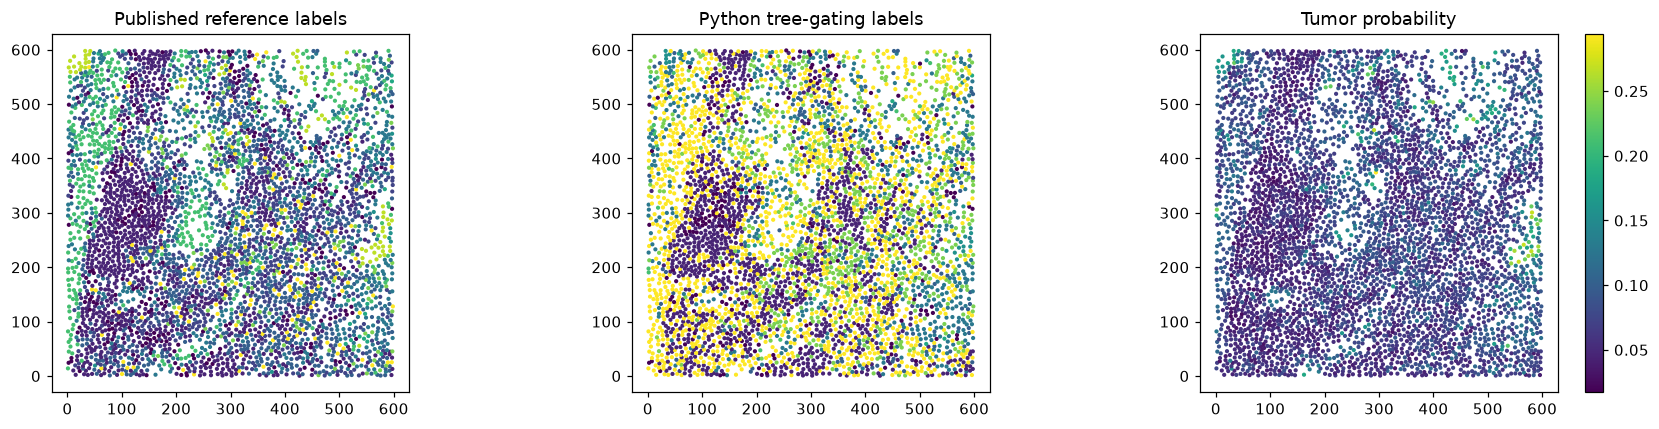

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_labelled_cells(adata, 'cell_type', ax=axes[0], s=3, title='Published reference labels')
plot_labelled_cells(adata, 'cell_type_hard', ax=axes[1], s=3, title='Python tree-gating labels')
plot_probability_map(adata, 'P_Tumor', ax=axes[2], s=3, title='Tumor probability')
plt.tight_layout()

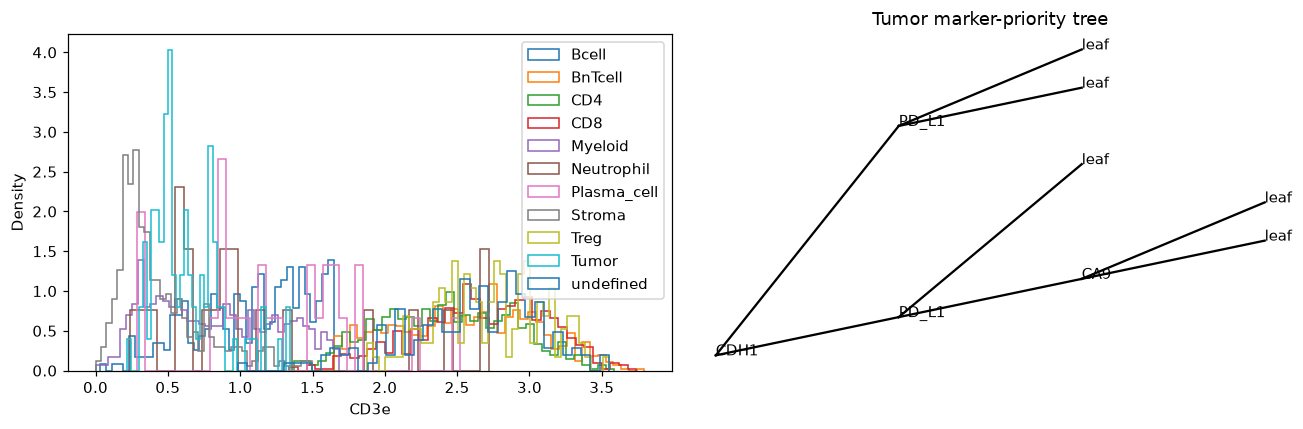

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_marker_density(adata, 'CD3e', label_col='cell_type', ax=axes[0])
plot_celltype_tree(tree_result['trees']['Tumor'], title='Tumor marker-priority tree', ax=axes[1])
plt.tight_layout()

## 4. Create training data from the selected gating result

`apply_cutoff_labels()` computes a separate 98th-percentile cutoff for each cell-type probability. A cell becomes a training candidate only when it passes exactly one cutoff. Cells passing zero or multiple cutoffs remain `Unknown`, matching the R vignette.

In [9]:
gating_result = cg.apply_cutoff_labels(
    gating_result,
    cutoff_fn=cg.prob_quantile_cutoff,
    label_col='cutoff_label',
    unknown_label='Unknown',
)
adata = gating_result['spe']
reference_counts = adata.obs['cutoff_label'].value_counts(dropna=False)
# Validate against the probability matrix actually used, not notebook state
# from a lineage_table cell that may have been rerun independently.
allowed_labels = set(map(str, gating_result['prob_mat'].columns)) | {'Unknown'}
observed_labels = set(adata.obs['cutoff_label'].dropna().astype(str).unique())
unexpected_labels = observed_labels - allowed_labels
if unexpected_labels:
    raise RuntimeError(
        f'Unexpected cutoff labels: {sorted(unexpected_labels)}. '
        'Restart the kernel and run all cells so the updated package and '
        'gating_result are loaded together.'
    )
if adata.obs['cutoff_label'].isna().any():
    raise RuntimeError('cutoff_label contains missing values; rerun gating and cutoff creation.')
print(f"Reference cells: {(adata.obs['cutoff_label'] != 'Unknown').sum():,} / {adata.n_obs:,}")
display(reference_counts)

Reference cells: 710 / 4,363


cutoff_label
Unknown        3653
BnTcell          88
CD8              88
Bcell            83
Stroma           82
CD4              76
Treg             76
Tumor            71
Plasma_cell      65
Myeloid          44
Neutrophil       37
Name: count, dtype: int64

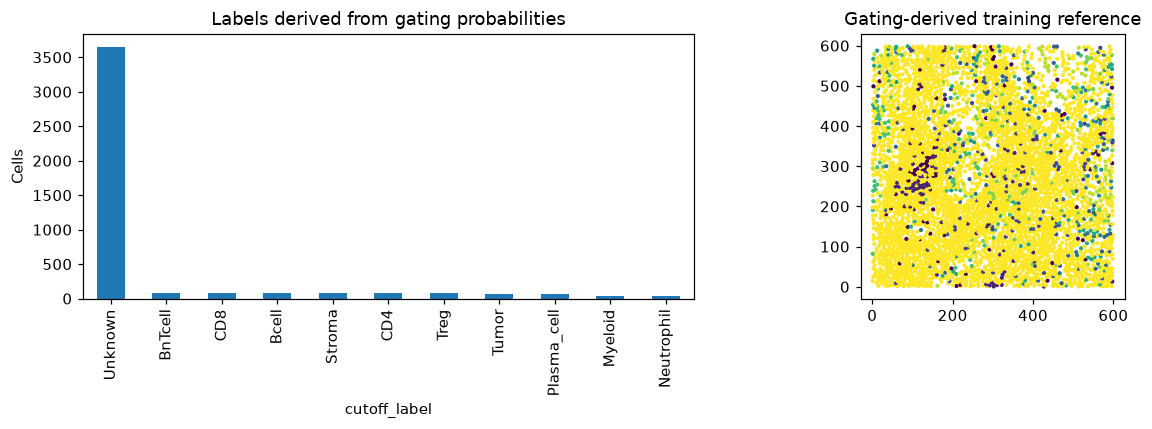

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
reference_counts.plot.bar(ax=axes[0], title='Labels derived from gating probabilities')
axes[0].set_ylabel('Cells')
plot_labelled_cells(adata, 'cutoff_label', ax=axes[1], s=3, title='Gating-derived training reference')
plt.tight_layout()

## 5. Clean the gating-derived reference and predict unknown cells

Both models train from `label_col='cutoff_label'`. Cross-validation changes inconsistent training candidates to `Unknown` in `cleaned_core_label`; prediction then fills cells outside that cleaned reference. A cutoff-derived class with fewer than two cells cannot be cross-validated and is also moved to `Unknown`.

In [11]:
knn_fit = train_custom_knn(
    adata, label_col='cutoff_label', cv_folds=3, repeats=2,
    agreement_thresh=0.5, k=5, method='pearson', seed=1,
)
knn_result = predict_unknown_with_knn(
    adata, knn_fit, label_col='cleaned_core_label', threshold=0.5, k=5,
)

rf_fit = train_custom_randomforest(
    adata, label_col='cutoff_label', num_trees=100, cv_folds=3,
    repeats=2, agreement_thresh=0.5, num_threads=1, seed=1,
)
rf_result = predict_unknown_with_randomforest(
    adata, rf_fit['model'], label_col='cleaned_core_label', threshold=0.5,
)
display(adata.obs[['cell_type', 'cutoff_label', 'knn_label_filled', 'soft_tree_label_filled']].head())

,cell_type,cutoff_label,knn_label_filled,soft_tree_label_filled
12_1,CD8,Unknown,CD8,Unassigned
12_2,Bcell,Unknown,Bcell,Bcell
12_3,BnTcell,BnTcell,BnTcell,BnTcell
12_4,BnTcell,Unknown,CD8,BnTcell
12_5,BnTcell,BnTcell,BnTcell,BnTcell


## 6. Evaluate predictions

In [12]:
tree_metrics = cg.calculate_f1(adata, ref_col='cell_type', pred_col='cell_type_hard')
knn_metrics = cg.calculate_f1(adata, ref_col='cell_type', pred_col='knn_label_filled')
rf_metrics = cg.calculate_f1(adata, ref_col='cell_type', pred_col='soft_tree_label_filled')
display(pd.concat({'tree': tree_metrics, 'kNN': knn_metrics, 'random forest': rf_metrics}, names=['method']))

Category  Precision  Recall  F1_Score  Cell_Count
method                                                               
tree          0        Bcell      0.661   0.542     0.596         284
              1      BnTcell      0.617   0.650     0.633        1033
              2          CD4      1.000   0.017     0.034         747
              3          CD8      0.901   0.198     0.325         736
              4      Myeloid      0.740   0.634     0.683         683
...                      ...        ...     ...       ...         ...
random forest 5   Neutrophil      0.393   0.524     0.449          21
              6  Plasma_cell      0.333   0.778     0.467          27
              7       Stroma      0.744   0.642     0.689         444
              8         Treg      0.365   0.790     0.499         138
              9        Tumor      0.725   0.898     0.802          88

[31 rows x 5 columns]

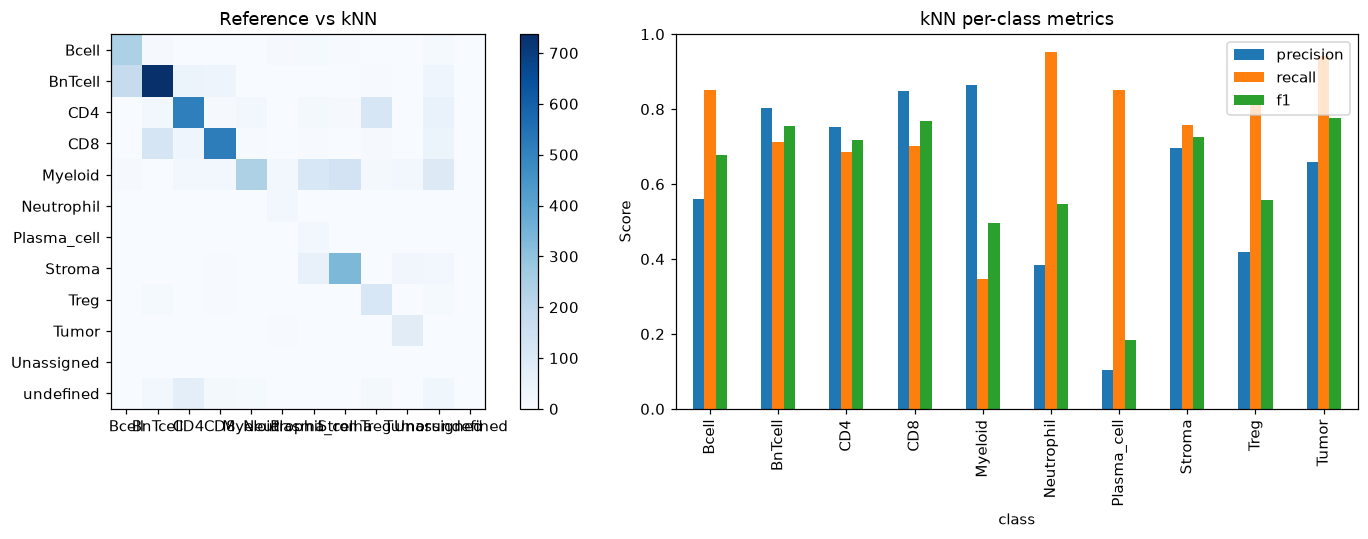

In [13]:
confusion = cg.label_confusion_matrix(adata, 'cell_type', 'knn_label_filled')
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_confusion_matrix(confusion, title='Reference vs kNN', ax=axes[0])
plot_class_metrics(knn_metrics.rename(columns={
    'Category': 'class', 'Precision': 'precision', 'Recall': 'recall', 'F1_Score': 'f1'
}), title='kNN per-class metrics', ax=axes[1])
plt.tight_layout()

## 7. Probability uncertainty and protected spatial priors

The packaged R demo already contains a complete `KNN_P_*` matrix. Using it here demonstrates uncertainty and spatial adjustment for every cell without filling artificial probabilities for reference cells.

In [14]:
r_knn_columns = [column for column in adata.obs if column.startswith('KNN_P_')]
full_probabilities = adata.obs[r_knn_columns].astype(float).copy()
full_probabilities.columns = [column.removeprefix('KNN_P_') for column in r_knn_columns]

uncertainty = calculate_uncertainty(
    full_probabilities, adata, sample_col='sample_id', k_spatial=15,
)
adata.obs[uncertainty.columns[1:]] = uncertainty.iloc[:, 1:]
calculate_spatial_prior_labels(
    adata, full_probabilities, k_spatial=15,
    lambda_=0.2, protect_threshold=0.85,
)
display(uncertainty.describe())

,entropy,gini_impurity,margin_uncertainty,spatial_discordance
count,4363.000000,4363.000000,4363.000000,4363.000000
mean,0.095018,0.164926,0.219078,0.677011
std,0.140225,0.240719,0.321931,0.242774
min,-0.000000,0.000000,0.000000,0.000000
25%,-0.000000,0.000000,0.000000,0.533333
50%,0.000000,0.000000,0.000000,0.733333
75%,0.275556,0.491666,0.660638,0.866667
max,0.538163,0.740740,0.999965,1.000000


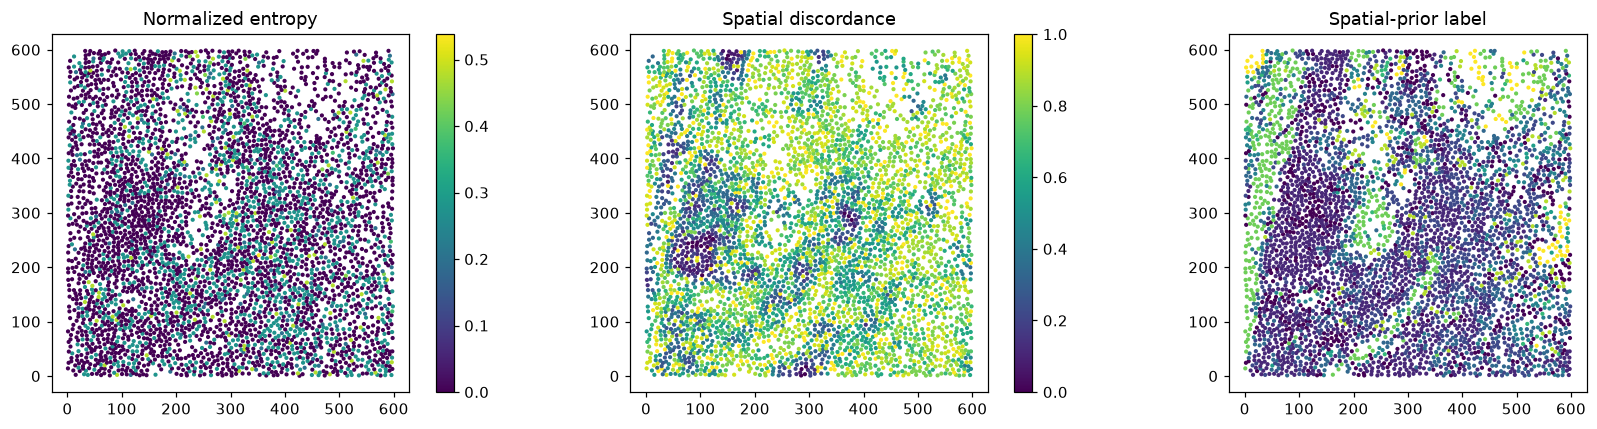

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_probability_map(adata, 'entropy', ax=axes[0], s=3, title='Normalized entropy')
plot_probability_map(adata, 'spatial_discordance', ax=axes[1], s=3, title='Spatial discordance')
plot_labelled_cells(adata, 'knn_spatial_label', ax=axes[2], s=3, title='Spatial-prior label')
plt.tight_layout()

## 8. Save the converted and annotated data

Tree dictionaries are ordinary Python return objects. The cell-level results are stored in `adata.obs` and probability matrices in `adata.obsm`.

In [16]:
output_path = Path.cwd() / 'cytogater_r_demo_python.h5ad'
if SAVE_OUTPUT:
    adata.write_h5ad(output_path)
    print(f'Saved {output_path}')
else:
    print('Set SAVE_OUTPUT = True in the first cell to save:', output_path)

Set SAVE_OUTPUT = True in the first cell to save: /dskh/nobackup/biostat/projects/PRJ-cytogater/cytoGateR/python/examples/cytogater_r_demo_python.h5ad
